In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import numpy as np
import os

import matplotlib.pyplot as plt
import torchvision
import torchvision.io as torchio
from torchvision.io import ImageReadMode 
from torchvision.transforms import Compose
import torchvision.transforms as transforms


In [ ]:

# class EnhancedUNet(nn.Module):
#     def __init__(self, in_channels=8, out_channels=1):
#         super().__init__()

#         self.base_model = smp.Unet(
#             encoder_name="resnet50",
#             encoder_weights="imagenet",
#             in_channels=in_channels,
#             classes=out_channels,
#         )

#         # Add CBAM attention to decoder
#         class CBAMBlock(nn.Module):
#             def __init__(self, channel, reduction=16):
#                 super().__init__()
#                 self.avg_pool = nn.AdaptiveAvgPool2d(1)
#                 self.max_pool = nn.AdaptiveMaxPool2d(1)
#                 self.fc = nn.Sequential(
#                     nn.Linear(channel, channel // reduction),
#                     nn.ReLU(inplace=True),
#                     nn.Linear(channel // reduction, channel),
#                     nn.Sigmoid()
#                 )
#                 self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
#                 self.sigmoid = nn.Sigmoid()

#             def forward(self, x):
#                 # Channel attention
#                 ca_avg = self.avg_pool(x)
#                 ca_max = self.max_pool(x)
#                 ca = self.fc(ca_avg.squeeze(-1).squeeze(-1)) + self.fc(ca_max.squeeze(-1).squeeze(-1))
#                 ca = self.sigmoid(ca.unsqueeze(-1).unsqueeze(-1))

#                 # Spatial attention
#                 sa_avg = torch.mean(x, dim=1, keepdim=True)
#                 sa_max, _ = torch.max(x, dim=1, keepdim=True)
#                 sa = torch.cat([sa_avg, sa_max], dim=1)
#                 sa = self.conv(sa)
#                 sa = self.sigmoid(sa)

#                 return x * ca * sa

#         # Modify decoder blocks
#         for i in range(len(self.base_model.decoder.blocks)):
#             self.base_model.decoder.blocks[i] = nn.Sequential(
#                 self.base_model.decoder.blocks[i],
#                 CBAMBlock(self.base_model.decoder.blocks[i][-1].conv2[0].out_channels)
#            )

#     def forward(self, x):
#         return self.base_model(x)

In [24]:
OUTPUT_FOLDER = "./images-and-masks/torch-data"

class PBRDataset(Dataset):
    def __init__(self, input_data_path, pbr_channels=7, transform=None):
        self.input_data_path = input_data_path
        self.transform = transform
        self.pbr_channels = pbr_channels

    def __len__(self):
        return len([data for data in os.listdir(os.path.join(self.input_data_path, "data"))])

    def __getitem__(self, idx):
        # Load multi-channel PBR maps (albedo, normal, roughness, metallic, etc.)
        pbr_map = torch.load(os.path.join(self.input_data_path, "data", f"data_{str(idx)}")).float()  # Shape: (C, H, W)
        mask = torch.load(os.path.join(self.input_data_path, "masks", f"mask_{str(idx)}")).float() # (2, H, W)

        pbr_map = pbr_map / 255.0  # Normalize to [0,1]
        mask = mask / 255.0  # Normalize mask to [0,1] (assuming stored as 0-255)

        if self.transform:
            pbr_map = self.transform(pbr_map)

        return pbr_map, mask
  

# Step 4: Modified Model for Multi-Mask Output
class MultiMaskUNet(nn.Module):
    def __init__(self, in_channels=8, out_channels=2):
        super().__init__()
        
        self.base_model = smp.Unet(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=out_channels,  # Output 2 channels
            activation=None  # We'll handle activation separately
        )
        
        # Add final activation
        self.final_activation = nn.Sigmoid()

    def forward(self, x):
        x = self.base_model(x)
        return self.final_activation(x)


DEVICE = "cpu" #"cuda" if torch.cuda.is_available() else "cpu"
IN_CHANNELS = 7  # Adjust based on PBR maps
NUM_CLASSES = 2  # Number of damage types
BATCH_SIZE = 4
LR = 0.0001
EPOCHS = 50

train_transform = Compose([
    #transforms.RandomRotate90(),
    #transforms.Flip(),
    transforms.Normalize(mean=[0.5]*IN_CHANNELS, std=[0.5]*IN_CHANNELS),
])

# Initialize dataset and dataloader (replace with your paths)
train_dataset = PBRDataset(
    input_data_path=OUTPUT_FOLDER,
    transform=train_transform
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model, loss, and optimizer
if os.path.exists("./saved_model.pth"):
    model = MultiMaskUNet(in_channels=IN_CHANNELS, out_channels=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load('./saved_model.pth', weights_only=True, map_location=torch.device('cpu') ))
else:
    model = MultiMaskUNet(in_channels=IN_CHANNELS, out_channels=NUM_CLASSES).to(DEVICE)


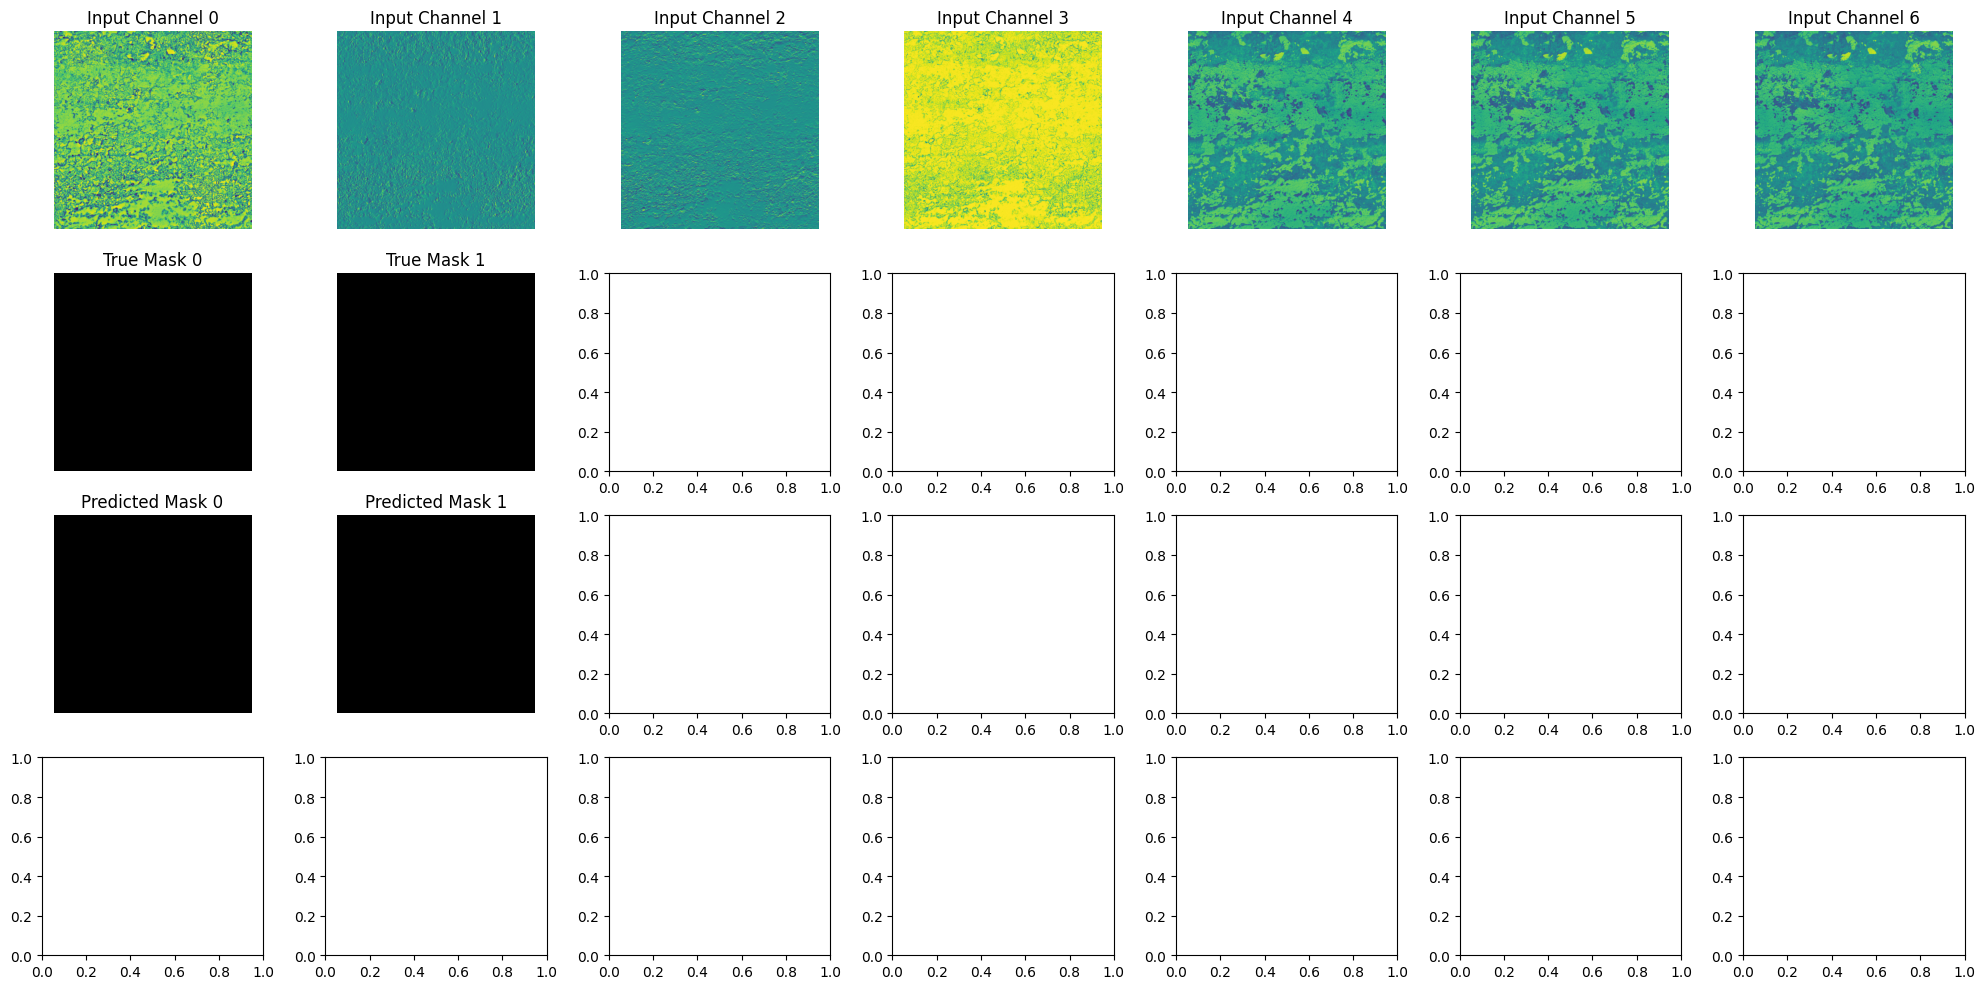

In [27]:
def run_inference(model , data_index=0, threshold=0.5):

    model.eval()
    
    # Get sample data
    sample_data, sample_mask = train_dataset[data_index]
    
    # Prepare input
    input_tensor = sample_data.unsqueeze(0).to(DEVICE)  # Add batch dimension
    
    # Predict
    with torch.no_grad():
        pred_masks = model(input_tensor).squeeze(0).cpu()
    
    # Convert to numpy arrays
    input_np = sample_data.numpy().transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    true_masks_np = sample_mask.numpy()
    pred_masks_np = pred_masks.numpy()
    
    # Threshold predictions
    pred_masks_np = (pred_masks_np > threshold).astype(np.float32)
    
    # Create figure
    fig, axes = plt.subplots(2 + NUM_CLASSES, input_np.shape[2], 
                            figsize=(20, 10))
    
    # Plot input channels
    for c in range(input_np.shape[2]):
        axes[0, c].imshow(input_np[..., c], cmap='viridis')
        axes[0, c].set_title(f'Input Channel {c}')
        axes[0, c].axis('off')
    
    # Plot ground truth masks
    for i in range(NUM_CLASSES):
        axes[1, i].imshow(true_masks_np[i], cmap='gray')
        axes[1, i].set_title(f'True Mask {i}')
        axes[1, i].axis('off')
    
    # Plot predicted masks
    for i in range(NUM_CLASSES):
        axes[2, i].imshow(pred_masks_np[i], cmap='gray')
        axes[2, i].set_title(f'Predicted Mask {i}')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
run_inference(model, data_index=0)